# BackTesting 

## Import libraries

In [1]:
import os, sys
processing_source_path = os.path.abspath('Processing/')
if(processing_source_path not in sys.path):
    sys.path.append(processing_source_path)
from DataLoaderPipeline import FeaturesDataGenerator, scrapingHistoricalData

In [2]:
import tensorflow as tf
import requests
import pandas as pd
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt

### Get the crypto data

In [3]:

SHD=scrapingHistoricalData()

# Lista de criptomoedas
#cryptos = ['BTC']
cryptos = ['BTC']

# Escolha o intervalo
interval = '4h'

# Obtenha os dados históricos
cryptos_df = SHD.get_crypto_historical_data(cryptos, interval, '2024-01-01')

In [4]:
features_indicators=['Data_lookback', 'Open', 'High', 'Low', 'Volume', 
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350', 
                    'MACD', 'MACD_Signal', 'MACD_Histogram', 'RSI_14', 'CCI',  
                    'Stochastic_K', 'Stochastic_D', 
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower']

features_indicators=['Data_lookback','Chaikin_Money_Flow',
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200',
                    'MACD', 'MACD_Signal', 'MACD_Histogram', 'RSI_14', 'CCI',  
                    'Stochastic_K', 'Stochastic_D', 
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower']

features_indicators=[
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200',
                    'MA111', 'MA350', 
                    #'RSI_14',  
                    #'MACD', 'MACD_Signal', 'MACD_Histogram',
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower']
                    #''CCI','Williams_R',  'ROC',  'PPO', 'Chaikin_Money_Flow']
features_indicators=['Data_lookback', 'Open', 'High', 'Low', 
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350', 
                    'RSI_14',  'Chaikin_Money_Flow',
                    'MACD', 'MACD_Signal', 'MACD_Histogram', 
                    'Stochastic_K', 'Stochastic_D', 
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                    'CCI',  'ROC',  'PPO', 'Chaikin_Money_Flow']

In [5]:
#pred_days = int(24/4 * 12) 
pred_days = int(24/4 * 2) 
buy_sell_threshold=[0.05,-0.05]
lookback = int(4 * 6) 
batch_size = 16
shuffle = True

min_norm=-1
max_norm=1
#ticker = 'BTC-USDT'
#list_of_models =['MLP', 'GRU', 'CNN_LSTM_MultiHead', 'CNN_MultiHead', 'LSTM', 'LSTM_AT']
list_of_models =['CNN_MultiHead_2D']


In [6]:
# features and dataloader parameters
features_indicators=['Close', 'Open', 'High', 'Low',  
                    'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350', 
                    'RSI_14', 
                    'MACD', 'MACD_Signal', 'MACD_Histogram', 
                    'Stochastic_K', 'Stochastic_D', 
                    'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                    'CCI',  'ROC', 'Chaikin_Money_Flow']

features_indicators=['SCP', 'RSI_14', 'Williams_R', 'MFI','MACD']

pred_days = 11
buy_sell_threshold=[0.05,-0.05]
lookback = 20
batch_size = 128
shuffle = True

min_norm=-1
max_norm=1

trade=['Hold','Buy','Sell']

# model parameters
input_shape = (lookback, len(features_indicators))
n_classes = len(trade)

datatype='2D'

In [7]:
features_indicators=['SCP', 'RSI_14', 'Williams_R', 'MFI','MACD',
                     'EMA9', 'EMA20', 'EMA50', 'EMA100', 'EMA200', 'MA111', 'MA350',
                     'Bollinger_Bands_Upper', 'Bollinger_Bands_Middle', 'Bollinger_Bands_Lower',
                     'CCI',  'ROC', 'Chaikin_Money_Flow']

#pred_days = 17 # last
pred_days = 25
buy_sell_threshold=[0.05,-0.05]

lookback = 40# 

batch_size = 128
shuffle = True
data_augmentation =True

min_norm=-1
max_norm=1

trade=['Hold','Buy','Sell']

# model parameters
input_shape = (lookback, len(features_indicators))
n_classes = len(trade)

datatype='2D'


In [8]:
dataGen_inference = FeaturesDataGenerator(cryptos_df,  datatype=datatype, lookback = lookback, 
                                          pred_days = pred_days, shuffle= False, batch_size=1, 
                                          selected_features = features_indicators, data_augmentation=False, 
                                          min_max_norm=[min_norm, max_norm])

self.pred_days 25
input data shape (2536, 40, 18)
output data shape (2536, 3)


### Load the model

In [9]:
from keras import backend as K
weighted_categorical_crossentropy_loss= dataGen_inference.weighted_categorical_crossentropy(np.ones(3))

def matthews_correlation_coefficient(y_true, y_pred):
    tp = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    tn = K.sum(K.round(K.clip((1 - y_true) * (1 - y_pred), 0, 1)))
    fp = K.sum(K.round(K.clip((1 - y_true) * y_pred, 0, 1)))
    fn = K.sum(K.round(K.clip(y_true * (1 - y_pred), 0, 1)))

    num = tp * tn - fp * fn
    den = (tp + fp) * (tp + fn) * (tn + fp) * (tn + fn)
    return num / K.sqrt(den + K.epsilon())

In [10]:
import tensorflow_addons as tfa
trained_best_models={}
for model_name in list_of_models:
    print(model_name)
    #checkpoint_filepath =f'models/model_{model_name}_stock_{ticker}_lookback_{lookback}'
    checkpoint_filepath =f'models/model_{model_name}_crypto_lookback_{lookback}_best'
    trained_best_models[f'{model_name}']=tf.keras.models.load_model(
        checkpoint_filepath,
        custom_objects={'loss': weighted_categorical_crossentropy_loss, 'matthews_correlation_coefficient': matthews_correlation_coefficient})

d:\Projetos_python\Time_Series_Forecast\.venv\lib\site-packages\tensorflow_addons\utils\tfa_eol_msg.py:23: UserWarning: 

TensorFlow Addons (TFA) has ended development and introduction of new features.
TFA has entered a minimal maintenance and release mode until a planned end of life in May 2024.
Please modify downstream libraries to take dependencies from other repositories in our TensorFlow community (e.g. Keras, Keras-CV, and Keras-NLP). 

For more information see: https://github.com/tensorflow/addons/issues/2807 

  warnings.warn(
d:\Projetos_python\Time_Series_Forecast\.venv\lib\site-packages\tensorflow_addons\utils\ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.12.0 and strictly below 2.15.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.15.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not 

CNN_MultiHead_2D





In [11]:
x_data_inference=dataGen_inference.comput_features(cryptos_df, pred_days=0)
x_data=dataGen_inference.apply_NomrMinmax(x_data_inference, min_norm, max_norm, axis=0)

if datatype == '2D':
    x_data = np.transpose(x_data, [0, 2, 1]).reshape(-1, 1, input_shape[1], input_shape[0])

model_name=f'CNN_MultiHead_{datatype}'
label_pred = trained_best_models[model_name].predict(x_data)

80/80 [==============================] - 1s 6ms/step


In [12]:
trained_best_models[model_name].summary()

Model: "CNN_MultiHead_2D"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_2 (InputLayer)        [(None, 1, 18, 40)]       0         
                                                                 
 conv2d_2 (Conv2D)           (None, 1, 18, 64)         23104     
                                                                 
 batch_normalization (Batch  (None, 1, 18, 64)         256       
 Normalization)                                                  
                                                                 
 activation (Activation)     (None, 1, 18, 64)         0         
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 1, 18, 64)         0         
 g2D)                                                            
                                                                 
 dropout_1 (Dropout)         (None, 1, 18, 64)    

In [13]:
label_pred

array([[9.8449755e-01, 1.4813672e-02, 6.8881200e-04],
       [8.5784256e-01, 1.4190607e-01, 2.5140590e-04],
       [5.1351923e-01, 4.8609877e-01, 3.8192963e-04],
       ...,
       [7.9828089e-01, 2.0047465e-01, 1.2444023e-03],
       [1.4815706e-01, 8.4893608e-01, 2.9069264e-03],
       [2.1792239e-01, 7.6369470e-01, 1.8382927e-02]], dtype=float32)

### Show inference

In [14]:
trade=['Hold','Buy','Sell']

In [15]:
label_data = dataGen_inference.label_data(close_prices=cryptos_df['Close'].values, window=16)


In [16]:
data_idx= -x_data_inference.shape[0]
input_data = cryptos_df['Close'].iloc[data_idx:].values
inference_date = cryptos_df['Date'].iloc[data_idx:]

TH = [0.5, 0.8, 0.]

trade_predictions = np.array([
    np.argmax(prediction) if np.max(prediction) > TH[np.argmax(prediction)] else 0
    for prediction in label_pred
])

pred_signals=[trade[label] for label in trade_predictions]
#pred_signals=[trade[label] for label in np.argmax(label_pred[:],axis=1)]
pred_signals=pred_signals[data_idx:]

cryptos_df['pred_signals']=['Hold']*len(cryptos_df)
cryptos_df['pred_signals'].iloc[data_idx:]= pred_signals

C:\Users\Public\Documents\Wondershare\CreatorTemp\ipykernel_26336\3257539120.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cryptos_df['pred_signals'].iloc[data_idx:]= pred_signals


In [17]:
#cryptos_df['label_data'] = ['Hold']*len(cryptos_df)


In [18]:
# Dados de exemplo
#close_price_list = cryptos_df['Close'].values
#labels = labelling_method(close_price_list, 60)
label_data = dataGen_inference.label_data(close_prices=cryptos_df['Close'], window= 17)

labels=[("BUY" if np.allclose(label, [0, 1, 0]) else "SELL" if np.allclose(label, [0, 0, 1]) else "HOLD") 
        for label in label_data]# Realizar o backtest

cryptos_df['label_data'] = labels

print('labeling method ',np.unique(labels, return_counts=True))
print('Predicted ',np.unique(cryptos_df['pred_signals'], return_counts=True))

# Realizar o backtest

signals=[trade[label] for label in np.argmax(label_pred[:],axis=1)]
signals=signals[data_idx:]

# Gráfico do desempenho
import plotly.graph_objects as go

#fig = go.Figure()

fig = go.Figure(data=[go.Candlestick(x=cryptos_df['Date'],
                open=cryptos_df['Open'],
                high=cryptos_df['High'],
                low=cryptos_df['Low'],
                close=cryptos_df['Close'],
                name='Candlestick')])


# Configuração do layout
fig.update_layout(
    title="Backtest de Estratégia de BUY, SELL, HOLD",
    xaxis_title="Data",
    yaxis_title="Valor",
    showlegend=False,
    width=1700,
    height=600,
    margin=dict(l=50, r=50, t=50, b=50)  # Margem esquerda, direita, superior e inferior
)


# Adiciona os marcadores BUY, SELL e HOLD
for i, label in enumerate(labels):

    if label == "BUY":
        fig.add_trace(go.Scatter(
            x=[cryptos_df['Date'].iloc[i]],
            y=[cryptos_df['Close'].iloc[i]- 0.03*cryptos_df['Close'].iloc[i]] ,
            mode='markers',
            marker=dict(color='green', size=10, symbol='triangle-up'),
            name='BUY'
        ))
    elif label == "SELL":
        fig.add_trace(go.Scatter(
            x=[cryptos_df['Date'].iloc[i]],
            y=[cryptos_df['Close'].iloc[i]+ 0.03*cryptos_df['Close'].iloc[i]],
            mode='markers',
            marker=dict(color='red', size=10, symbol='triangle-down'),
            name='SELL'
        ))
    
    if cryptos_df['pred_signals'].iloc[i] == "Buy":
        fig.add_trace(go.Scatter(
            x=[cryptos_df['Date'].iloc[i]],
            y=[cryptos_df['Close'].iloc[i]- 0.06*cryptos_df['Close'].iloc[i]] ,
            mode='markers',
            marker=dict(color='white', size=10, symbol='diamond'),
            name='pred BUY'
        ))
    elif cryptos_df['pred_signals'].iloc[i] == "Sell":
        fig.add_trace(go.Scatter(
            x=[cryptos_df['Date'].iloc[i]],
            y=[cryptos_df['Close'].iloc[i]+ 0.06*cryptos_df['Close'].iloc[i]],
            mode='markers',
            marker=dict(color='black', size=10, symbol='diamond'),
            name='pred SELL'
        ))
        
fig.update_layout(xaxis_rangeslider_visible=False)
fig.show()


labeling method  (array(['BUY', 'HOLD', 'SELL'], dtype='<U4'), array([ 142, 2291,  143], dtype=int64))
Predicted  (array(['Buy', 'Hold', 'Sell'], dtype=object), array([ 153, 2068,  355], dtype=int64))


In [19]:
len(signals)


2536

In [20]:
import numpy as np

# Calcular as métricas de dispersão
media = np.mean(np.max(label_pred, axis=1))
desvio_padrao = np.std(np.max(label_pred, axis=1))
quartil_25 = np.percentile(np.max(label_pred, axis=1), 25)
quartil_75 = np.percentile(np.max(label_pred, axis=1), 75)

print(f'Média: {media:.2f}')
print(f'Desvio Padrão: {desvio_padrao:.2f}')
print(f'Quartil 25%: {quartil_25:.2f}')
print(f'Quartil 75%: {quartil_75:.2f}')

Média: 0.80
Desvio Padrão: 0.14
Quartil 25%: 0.70
Quartil 75%: 0.93


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


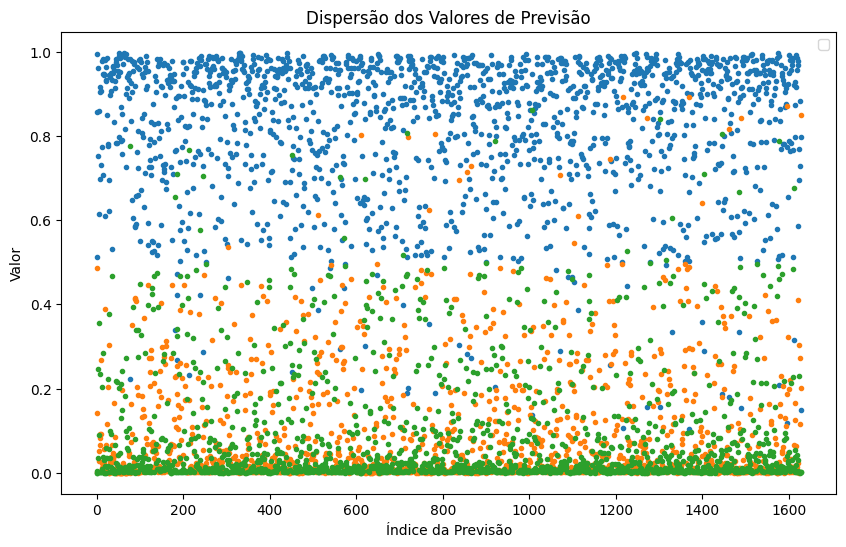

In [21]:
import matplotlib.pyplot as plt

# Plotar o gráfico scatter

idxs = [i for i, (x, y) in enumerate(zip(labels, signals)) if x.lower() == y.lower()]

plt.figure(figsize=(10, 6))
for i in range(label_pred.shape[1]):
    #plt.scatter(np.arange(len(label_pred)), label_pred[:, i], label=f'Classe {i}')

    plt.scatter(np.arange(len(label_pred[idxs, i])), label_pred[idxs, i], marker='.')

plt.xlabel('Índice da Previsão')
plt.ylabel('Valor')
plt.title('Dispersão dos Valores de Previsão')
plt.legend()
plt.show()

In [22]:
import numpy as np
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import accuracy_score

# Calcule a curva ROC para cada classe
for i in range(label_pred.shape[1]):
    fpr, tpr, thresholds = roc_curve(label_data[40:, i], label_pred[:, i])
    roc_auc = auc(fpr, tpr)
    
    # Encontre o valor de threshold que maximize a área sob a curva ROC
    idx = np.argmax(tpr - fpr)
    th = thresholds[idx]
    
    # Avalie o desempenho do modelo com o valor de threshold encontrado
    y_pred = (label_pred[:, i] >= th).astype(int)
    accuracy = accuracy_score(label_data[40:, i], y_pred)
    
    print(f'Classe {i}: th = {th:.2f}, Acurácia = {accuracy:.2f}')

Classe 0: th = 0.53, Acurácia = 0.71
Classe 1: th = 0.31, Acurácia = 0.81
Classe 2: th = 0.08, Acurácia = 0.71


In [23]:
# Classe para gerenciar o backtesting
import matplotlib.pyplot as plt

class Backtester:
    def __init__(self, initial_balance, data, transaction_cost=0.0001):
        self.initial_balance = initial_balance
        self.data = data
        self.balance = initial_balance
        self.position = 0
        self.portfolio_value = []
        self.transaction_cost = transaction_cost
        self.trades = []

    def execute_trade(self, signal, price):
        if signal == 'Buy':
            if self.balance > 0:
                cost = self.balance * self.transaction_cost
                self.position = (self.balance - cost) / price
                self.trades.append({'Action': 'Buy', 'Price': price, 'Position': self.position})
                self.balance = 0
        
        elif signal == 'Sell':
            if self.position > 0:
                proceeds = self.position * price
                cost = proceeds * self.transaction_cost
                self.balance = proceeds - cost
                self.trades.append({'Action': 'Sell', 'Price': price, 'Balance': self.balance})
                self.position = 0

        elif signal not in ['Hold']:
            print('balance:',self.balance)
            print('positi:',self.position)
            raise ValueError(f"Invalid signal: {signal}")

    def run(self, signals):
        for i in range(len(self.data)):
            price = self.data['Close'].iloc[i]
            signal = signals[i]
            self.execute_trade(signal, price)
            portfolio_value = self.balance + (self.position * price)
            self.portfolio_value.append(portfolio_value)

    def plot_portfolio_value(self):
        plt.figure(figsize=(10, 6))
        plt.plot(self.portfolio_value, label='Portfolio Value')
        plt.title('Portfolio Value Over Time')
        plt.xlabel('Time')
        plt.ylabel('Portfolio Value')
        plt.legend()
        plt.show()

    def calculate_metrics(self):
        final_portfolio_value = self.portfolio_value[-1]
        roi = (final_portfolio_value - self.initial_balance) / self.initial_balance * 100
        max_drawdown = min(self.portfolio_value) / self.initial_balance - 1
        return {
            'Final Portfolio Value': final_portfolio_value,
            'ROI (%)': roi,
            'Max Drawdown (%)': max_drawdown * 100
        }

# Função para gerar sinais fictícios
def generate_signals(signals):
    trade_signals = ['Hold']
    for i in range(1,len(signals)):
        if signals[i] == 'Buy' and signals[i-1] == 'Buy':
            trade_signals.append('Hold')
        elif signals[i] == 'Buy' and signals[i-1] == 'Hold':
            trade_signals.append('Buy')
        elif signals[i] == 'Sell' and signals[i-1] == 'Sell':
            trade_signals.append('Hold')
        elif signals[i] == 'Sell' and signals[i-1] == 'Hold':
            trade_signals.append('Sell')
        else:
            trade_signals.append('Hold')


    return trade_signals

d:\Projetos_python\Time_Series_Forecast\acoes\Processing\DataLoaderPipeline.py:1084: RuntimeWarning:

divide by zero encountered in log



479/479 [==============================] - 3s 6ms/step
(array(['Buy', 'Hold', 'Sell'], dtype='<U4'), array([ 1316, 12649,  1363], dtype=int64))


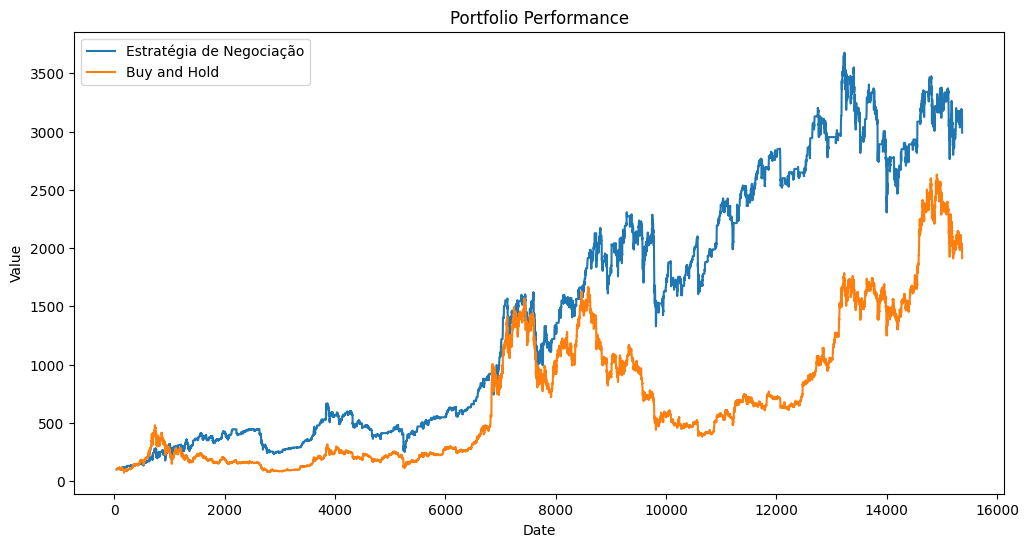

Retorno da Estratégia de Negociação: 2890.52%
Retorno da Estratégia de Buy and Hold: 1813.50%


In [24]:


# Parâmetros iniciais
interval = '4h'
start_time = '2015-01-01'
initial_balance = 100

symbol = cryptos
# Coleta de dados
data = SHD.get_crypto_historical_data(symbol, interval, start_time)

if data.empty:
    print("Nenhum dado encontrado.")
else:
    # Geração de sinais e backtesting

    x_data_inference=dataGen_inference.comput_features(data, pred_days=0)
    x_data=dataGen_inference.apply_NomrMinmax(x_data_inference, min_norm, max_norm, axis=0)
    
    if datatype == '2D':
        x_data = np.transpose(x_data, [0, 2, 1]).reshape(-1, 1, input_shape[1], input_shape[0])
    #list_of_models =['MLP', 'GRU', 'CNN_LSTM_MultiHead', 'CNN_MultiHead', 'LSTM', 'LSTM_AT']
    model_name=f'CNN_MultiHead_{datatype}'
    label_pred = trained_best_models[model_name].predict(x_data)

    #signals = [trade[label] for label in np.argmax(label_pred[:], axis=1)]
    #TH = [0.5, 0.7, 0.55]
    TH = [0.5, 0.75, 0.65]
    #TH = [0.5, 0.4, 0.40]
    signals = np.array([
        trade[np.argmax(prediction)] if np.max(prediction) > TH[np.argmax(prediction)] else trade[0]
        for prediction in label_pred
    ])


    print(np.unique(signals, return_counts=True))
    trade_signals=generate_signals(signals)
    
    #trade_signals=signals
    data=data.iloc[-len(signals):,:]


    backtester = Backtester(initial_balance, data)
    backtester.run(trade_signals)
    #backtester.plot_results()

    # Estratégia de buy and hold
    buy_and_hold = Backtester(initial_balance, data)
    signals = ['Buy'] + ['Hold'] * (len(data) - 1)
    buy_and_hold.run(signals)
    buy_and_hold_value = buy_and_hold.portfolio_value

    # Plotar resultados
    plt.figure(figsize=(12, 6))
    plt.plot(backtester.data.index, backtester.portfolio_value, label='Estratégia de Negociação')
    plt.plot(buy_and_hold.data.index, buy_and_hold_value, label='Buy and Hold')
    plt.xlabel('Date')
    plt.ylabel('Value')
    plt.title('Portfolio Performance')
    plt.legend()
    plt.show()

    # Calcular retorno
    backtester_return = (backtester.portfolio_value[-1] - initial_balance) / initial_balance
    buy_and_hold_return = (buy_and_hold_value[-1] - initial_balance) / initial_balance

    print(f"Retorno da Estratégia de Negociação: {backtester_return * 100:.2f}%")
    print(f"Retorno da Estratégia de Buy and Hold: {buy_and_hold_return * 100:.2f}%")

(array(['Buy', 'Hold', 'Sell'], dtype='<U4'), array([  938, 12785,  1605], dtype=int64))


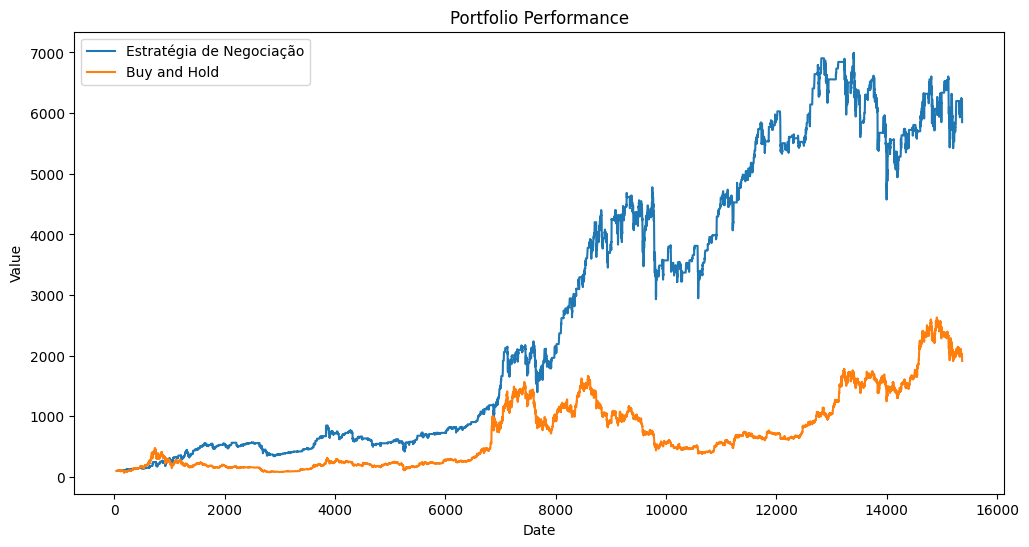

Modelo: {'Final Portfolio Value': 5851.231848819507, 'ROI (%)': 5751.231848819507, 'Max Drawdown (%)': -13.893644332241317}
BuyHold: {'Final Portfolio Value': 1913.501839980943, 'ROI (%)': 1813.5018399809428, 'Max Drawdown (%)': -29.05442378603844}


In [25]:
TH = [0.5, 0.8, 0.6]
#TH = [0.5, 0.4, 0.40]
signals = np.array([
    trade[np.argmax(prediction)] if np.max(prediction) > TH[np.argmax(prediction)] else trade[0]
    for prediction in label_pred
])


print(np.unique(signals, return_counts=True))
trade_signals=generate_signals(signals)

#trade_signals=signals
data=data.iloc[-len(signals):,:]


backtester = Backtester(initial_balance, data)
backtester.run(trade_signals)
#backtester.plot_results()

# Estratégia de buy and hold
buy_and_hold = Backtester(initial_balance, data)
signals = ['Buy'] + ['Hold'] * (len(data) - 1)
buy_and_hold.run(signals)
buy_and_hold_value = buy_and_hold.portfolio_value

# Plotar resultados
plt.figure(figsize=(12, 6))
plt.plot(backtester.data.index, backtester.portfolio_value, label='Estratégia de Negociação')
plt.plot(buy_and_hold.data.index, buy_and_hold_value, label='Buy and Hold')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Portfolio Performance')
plt.legend()
plt.show()

# Calcular retorno
backtester_return = (backtester.portfolio_value[-1] - initial_balance) / initial_balance
buy_and_hold_return = (buy_and_hold_value[-1] - initial_balance) / initial_balance

#print(f"Retorno da Estratégia de Negociação: {backtester_return * 100:.2f}%")
#print(f"Retorno da Estratégia de Buy and Hold: {buy_and_hold_return * 100:.2f}%")

print(f"Modelo: {backtester.calculate_metrics()}")
print(f"BuyHold: {buy_and_hold.calculate_metrics()}")

In [26]:
data['Close'].values.shape

(15328,)

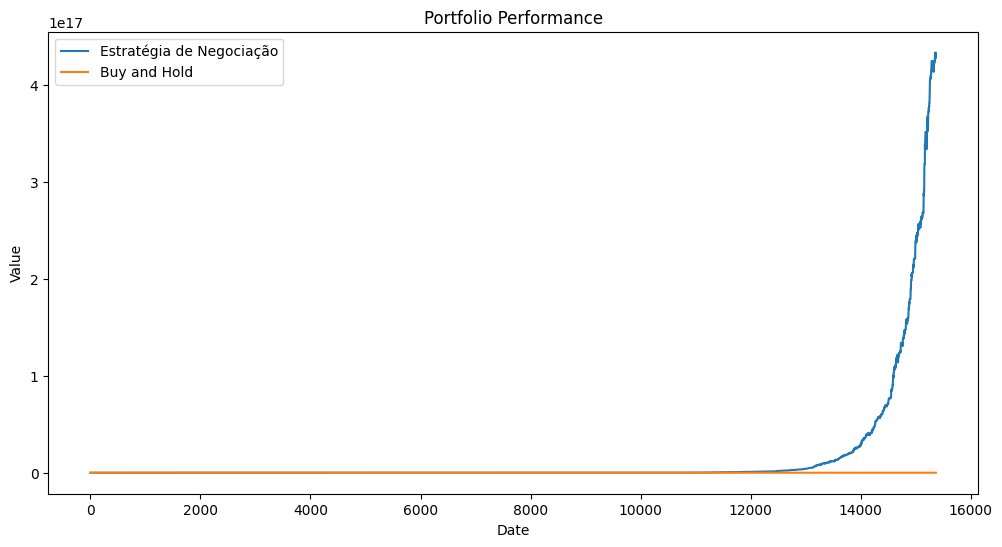

Retorno da Estratégia de Negociação: 427881000424271552.00%
Retorno da Estratégia de Buy and Hold: 1709.33%


In [27]:
data = SHD.get_crypto_historical_data(symbol, interval, start_time)

label_data = dataGen_inference.label_data(close_prices=data['Close'].values, window=16)

trade_signals=[("Buy" if np.allclose(label, [0, 1, 0]) else "Sell" if np.allclose(label, [0, 0, 1]) else "Hold") 
        for label in label_data]# Realizar o backtest

data=data.iloc[:len(trade_signals),:]

backtester = Backtester(initial_balance, data)
backtester.run(trade_signals)

# Estratégia de buy and hold
buy_and_hold = Backtester(initial_balance, data)
signals = ['Buy'] + ['Hold'] * (len(data) - 1)
buy_and_hold.run(signals)
buy_and_hold_value = buy_and_hold.portfolio_value

# Plotar resultados
plt.figure(figsize=(12, 6))
plt.plot(backtester.data.index, backtester.portfolio_value, label='Estratégia de Negociação')
plt.plot(buy_and_hold.data.index, buy_and_hold_value, label='Buy and Hold')
plt.xlabel('Date')
plt.ylabel('Value')
plt.title('Portfolio Performance')
plt.legend()
plt.show()

# Calcular retorno
backtester_return = (backtester.portfolio_value[-1] - initial_balance) / initial_balance
buy_and_hold_return = (buy_and_hold_value[-1] - initial_balance) / initial_balance

print(f"Retorno da Estratégia de Negociação: {backtester_return * 100:.2f}%")
print(f"Retorno da Estratégia de Buy and Hold: {buy_and_hold_return * 100:.2f}%")

In [28]:
clear data

In [ ]:
# Avaliação do desempenho do modelo
import time

import pandas as pd
import numpy as np
from datetime import datetime, timedelta

# Parâmetros iniciais

symbol = cryptos
last_timestamp = pd.Timestamp('2020-02-05 16:00:00')

interval = '4h'
datatype = '2D'  # ajuste o tipo de dados
trade = ["Hold", "Buy", "Sell"]  # ajuste as opções de trade

# Simulação de entradas e saídas do mercado
positions = []
initial_balance = 100
balance = initial_balance
fees = 0.002  # taxa de transação

def check_and_execute(symbol, last_timestamp, interval, balance = 100):
    today = datetime.today()
    
    # Coleta de dados
    window_days=today - timedelta(days=60)
    start_time = window_days.strftime('%Y-%m-%d')
    data = SHD.get_crypto_historical_data(symbol, interval, start_time)
    current_timestamp = data.loc[len(data)-1,'Date']
    
    #if last_timestamp != current_timestamp:
    symbol = cryptos
    
    x_data_inference = dataGen_inference.comput_features(data, pred_days=0)
    x_data = dataGen_inference.apply_NomrMinmax(x_data_inference, min_norm, max_norm, axis=0)
    
    if datatype == '2D':
        x_data = np.transpose(x_data, [0, 2, 1]).reshape(-1, 1, input_shape[1], input_shape[0])
    
    model_name = f'CNN_MultiHead_{datatype}'
    label_pred = trained_best_models[model_name].predict(x_data)
    
    TH = [0.5, 0.75, 0.65]
    trade_signals = np.array([
        trade[np.argmax(prediction)] if np.max(prediction) > TH[np.argmax(prediction)] else trade[0]
        for prediction in label_pred
    ])
    
    trade_signals = generate_signals(trade_signals)
    
    print(f'suggestion {trade_signals[-2:]} >> timestamp: {current_timestamp}')
    

    if last_timestamp != current_timestamp:
        # Verificar se é um sinal de entrada
        if trade_signals[-2] != "Hold":
            # Verificar se é uma compra ou venda
            if trade_signals[-2] == "Buy":
                # Comprar
                if balance > 0:  # Só compra se tiver saldo
                    price = data.loc[len(data)-1, 'Close']
                    position_value = (balance * (1 - fees)) / price  # Calcula quantas moedas comprou
                    balance = 0  # Zera o saldo pois tudo foi convertido em cripto
                    positions.append((current_timestamp, price, position_value))
                    print(f'Comprado em {current_timestamp} por {price} com {position_value} moedas')
            elif trade_signals[-2] == "Sell":
                # Vender
                if positions:  # Só vende se tiver posições
                    position = positions.pop(0)
                    price = data.loc[len(data)-1, 'Close']
                    balance = position[2] * price * (1 - fees)  # Calcula novo saldo
                    profit = balance - initial_balance
                    position_value = 0  # Zera o valor da posição
                    print(f'Vendido em {current_timestamp} por {price} com balance {balance:.2f} e lucro {profit:.2f}')
                else:
                    print(f'Não há posições para vender em {current_timestamp}')
        
        last_timestamp = current_timestamp
        
        return label_pred, last_timestamp, balance
    else:
        return None, last_timestamp, balance

while True:
    try:
        label_pred, last_timestamp, balance = check_and_execute(symbol, last_timestamp, interval, balance)
    except Exception as e:
        print(e)
    time.sleep(1200)  # Aguarda 10 minutos (600 segundos)

11/11 [==============================] - 0s 8ms/step
suggestion ['Buy', 'Hold'] >> timestamp: 2025-04-06 20:00:00
Comprado em 2025-04-06 20:00:00 por 78669.42 com 0.0012685996668082718 moedas
11/11 [==============================] - 0s 10ms/step
suggestion ['Buy', 'Hold'] >> timestamp: 2025-04-06 20:00:00
11/11 [==============================] - 0s 6ms/step
suggestion ['Buy', 'Hold'] >> timestamp: 2025-04-06 20:00:00


In [ ]:
import time

# Parâmetros iniciais

from datetime import datetime, timedelta

symbol = cryptos

last_timestamp = pd.Timestamp('2020-02-05 16:00:00')

def check_and_execute(symbol, last_timestamp, interval = '4h'):
    today = datetime.today()
    
    # Coleta de dados
    data = SHD.get_crypto_historical_data(symbol, interval, today.strftime('%Y-%m-%d'))
    current_timestamp = data.loc[len(data)-1,'Date']
    
    if last_timestamp != current_timestamp:
        window_days=today - timedelta(days=60)
        start_time = window_days.strftime('%Y-%m-%d')
        data = SHD.get_crypto_historical_data(symbol, interval, start_time)

        initial_balance = 100
        symbol = cryptos
        
        #x_data_inference = dataGen_inference.comput_features(data.iloc[-(lookback+1):,:], pred_days=0)
        x_data_inference = dataGen_inference.comput_features(data, pred_days=0)
        x_data = dataGen_inference.apply_NomrMinmax(x_data_inference, min_norm, max_norm, axis=0)
        
        if datatype == '2D':
            x_data = np.transpose(x_data, [0, 2, 1]).reshape(-1, 1, input_shape[1], input_shape[0])
        
        model_name = f'CNN_MultiHead_{datatype}'
        label_pred = trained_best_models[model_name].predict(x_data)
        
        trade_signals = [("Buy" if label == 1 else "Sell" if label==2 else "Hold") 
                          for label in np.argmax(label_pred, axis=1)]
        
        print(f'suggestion {trade_signals[-2:]} >> timestamp: {current_timestamp}')
        last_timestamp = current_timestamp

        return label_pred, last_timestamp
    else:
         return None, last_timestamp
while True:
    label_pred, last_timestamp = check_and_execute(symbol, last_timestamp, '4h')
    time.sleep(300)  # Aguarda 10 minutos (600 segundos)

11/11 [==============================] - 0s 12ms/step
suggestion ['Buy', 'Buy'] >> timestamp: 2025-03-28 08:00:00
11/11 [==============================] - 0s 13ms/step
suggestion ['Hold', 'Buy'] >> timestamp: 2025-03-28 12:00:00
11/11 [==============================] - 0s 9ms/step
suggestion ['Buy', 'Hold'] >> timestamp: 2025-03-28 16:00:00
11/11 [==============================] - 1s 24ms/step
suggestion ['Buy', 'Hold'] >> timestamp: 2025-03-28 20:00:00


In [ ]:
pd.Timestamp('2020-02-05 16:00:00')

Timestamp('2020-02-05 16:00:00')

In [ ]:
last_timestamp

Timestamp('2025-03-27 20:00:00')

In [ ]:
trade_signals = [("Buy" if label == 1 else "Sell" if label==2 else "Hold") 
                          for label in np.argmax(label_pred, axis=1)]

In [ ]:
trade_signals[-10:]

['Hold', 'Buy', 'Buy', 'Hold', 'Hold', 'Hold', 'Buy', 'Hold', 'Hold', 'Hold']

In [ ]:
np.argmax(label_pred,axis=1)[-10:]

array([0, 1, 1, 0, 0, 0, 1, 0, 0, 0], dtype=int64)

In [ ]:
x_data_inference=dataGen_inference.comput_features(cryptos_df, pred_days=0)
x_data=dataGen_inference.apply_NomrMinmax(x_data_inference, min_norm, max_norm, axis=0)

if datatype == '2D':
    x_data = np.transpose(x_data, [0, 2, 1]).reshape(-1, 1, input_shape[1], input_shape[0])

model_name=f'CNN_MultiHead_{datatype}'
label_pred = trained_best_models[model_name].predict(x_data)

78/78 [==============================] - 1s 9ms/step


In [ ]:
np.zeros(3)[np.argmax(label_pred[0])]

0.0

In [ ]:
for y_pred in label_pred

array([[9.8449755e-01, 1.4813672e-02, 6.8881200e-04],
       [8.5784256e-01, 1.4190607e-01, 2.5140590e-04],
       [5.1351923e-01, 4.8609877e-01, 3.8192963e-04],
       ...,
       [4.5750672e-01, 5.3916365e-01, 3.3296482e-03],
       [9.6091992e-01, 3.1570438e-02, 7.5095603e-03],
       [6.6009182e-01, 3.3350638e-01, 6.4018569e-03]], dtype=float32)

In [ ]:

# Encontrar os índices dos valores máximos em cada linha
max_indices = np.argmax(label_pred, axis=1)

# Criar uma matriz de zeros com a mesma forma dos dados originais
result = np.zeros_like(label_pred)

# Atribuir 1 aos elementos que são os máximos em cada linha
result[np.arange(result.shape[0]), max_indices] = 1

print(result)

[[1. 0. 0.]
 [1. 0. 0.]
 [1. 0. 0.]
 ...
 [0. 1. 0.]
 [1. 0. 0.]
 [1. 0. 0.]]
